<a href="https://colab.research.google.com/github/oluchiokoro-debug/colab-git-assignment2-OO/blob/main/sentiment_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import imdb
import numpy as np
import pandas as pd

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
word_index = imdb.get_word_index()

reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded_review])

df_train = pd.DataFrame({
    "review": [decode_review(x) for x in X_train],
    "sentiment": y_train
})

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
df_train.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

df_train["clean_review"] = df_train["review"].apply(clean_text)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df_train["clean_review"])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df_train["clean_review"])

In [ ]:
!pip install gensim
from gensim.models import Word2Vec

sentences = [text.split() for text in df_train["clean_review"]]

w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2)

def vectorize(sentence):
    words = sentence.split()
    vecs = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    return np.mean(vecs, axis=0) if len(vecs) > 0 else np.zeros(100)

X_w2v = np.array([vectorize(text) for text in df_train["clean_review"]])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.9 MB/s eta 0:00:00


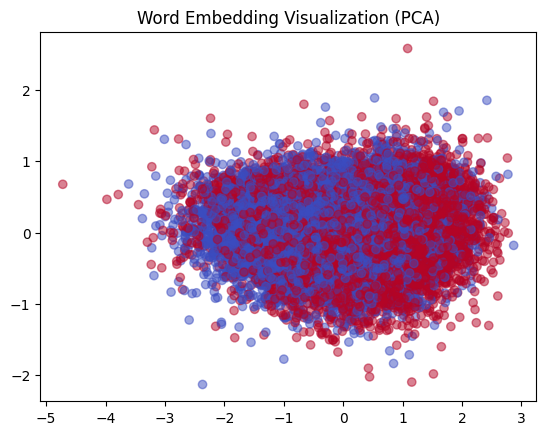

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_w2v)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df_train["sentiment"], cmap="coolwarm", alpha=0.5)
plt.title("Word Embedding Visualization (PCA)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_tfidf, df_train["sentiment"], test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train_vec, y_train)

LogisticRegression(max_iter=200)

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_vec, y_train)

LinearSVC()

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {"C": [0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=200), params, cv=3)
grid.fit(X_train_vec, y_train)

print(grid.best_params_)

{'C': 1}


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_lr = lr.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.8784
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      2437
           1       0.87      0.89      0.88      2563

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000

[[2100  337]
 [ 271 2292]]


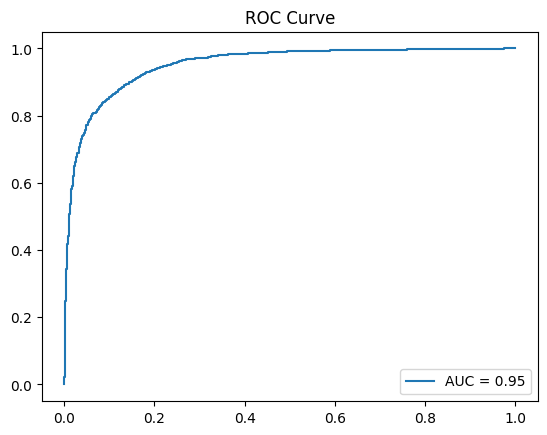

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = lr.decision_function(X_test_vec)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve")
plt.show()

In [ ]:
!pip install transformers datasets torch

In [ ]:
from transformers import pipeline

sentiment_pipeline = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [ ]:
sentiment_pipeline("This movie was absolutely amazing!")

[{'label': 'POSITIVE', 'score': 0.9998781681060791}]

In [ ]:
import joblib
joblib.dump(lr, "sentiment_model.pkl")

['sentiment_model.pkl']